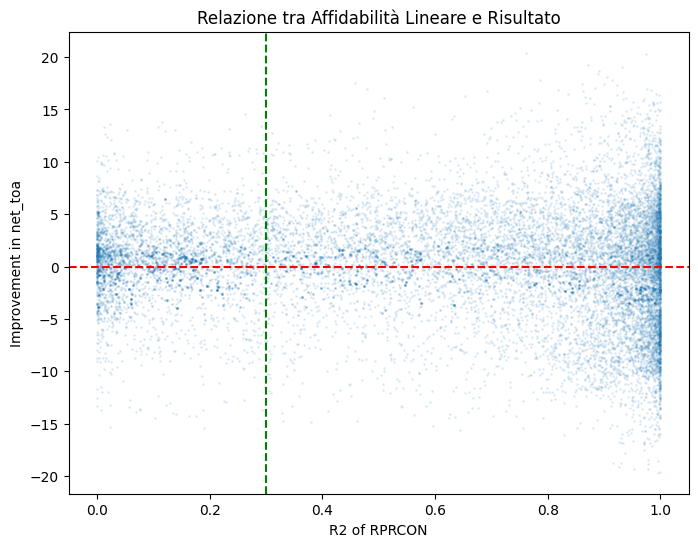

In [ ]:
#risponde alla domanda: "Il modello migliora davvero nelle zone dove la sensibilità del parametro è affidabile?"

import matplotlib.pyplot as plt
import xarray as xr

ds_diag = xr.open_dataset('tuned_2d_LR/alfa_1/diagnostics_2d_phis_Global_a1.nc')
ds_sens = xr.open_dataset('../../ectuner/sensitivities/2D/sensitivity_TL63_415_1991-2000_2D.nc')

var = 'net_toa'
param = 'RPRCON' 

# grid alignment
r2 = ds_sens.sel(variable=var, parameter=param).r2
improv = ds_diag[f'{var}_improvement']

plt.figure(figsize=(8, 6))
plt.scatter(r2.values.flatten(), improv.values.flatten(), alpha=0.1, s=1)
plt.axhline(0, color='red', linestyle='--') # Sotto questa linea il bias è peggiorato
plt.axvline(0.3, color='green', linestyle='--') # Il tuo threshold
plt.xlabel(f'R2 of {param}')
plt.ylabel(f'Improvement in {var}')
plt.title(f'Relazione tra Affidabilità Lineare e Risultato')
plt.show()